In [4]:
from tiffany_rf import evaluate_forest, evaluate_forest_classes
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
parkinsons_df = pd.read_csv("../res/parkinsons.csv")
credit_df = pd.read_csv("../res/credit_approval.csv")
rice_df = pd.read_csv("../res/rice.csv")

In [ ]:
ntrees = [1, 5, 10, 20, 30, 40, 50]
parkinsons_metrics = evaluate_forest(parkinsons_df, ntrees, 'Diagnosis', max_depth=10)
credit_metrics = evaluate_forest(credit_df, ntrees, 'label', max_depth=10)

Finished 1 trees
Finished 5 trees
Finished 10 trees
Finished 20 trees
Finished 30 trees
Finished 40 trees
Finished 50 trees
Finished 1 trees
Finished 5 trees
Finished 10 trees
Finished 20 trees
Finished 30 trees
Finished 40 trees
Finished 50 trees


In [5]:
def plot_metrics(ntree_to_metrics, dataset_name):
    data = pd.DataFrame.from_dict(
        ntree_to_metrics,
        orient='index',
        columns=['accuracy', 'precision', 'recall', 'f1']
    )
    
    p = sns.lineplot(data)
    plt.xlabel("ntrees")
    plt.title(f"{dataset_name} dataset")
    plt.show()
    p.get_figure().savefig(f"../figures/{dataset_name}.png")

    for metric in ['accuracy', 'f1']:
        sns.set_theme()
        p = sns.lineplot(x=data.index, y=metric, data=data)
        p.set(xlabel='ntree')
        p.set_title(f"{dataset_name}: Ntree vs {metric.capitalize()}")
        plt.show()
        p.get_figure().savefig(f"../figures/{dataset_name}_{metric}.png")

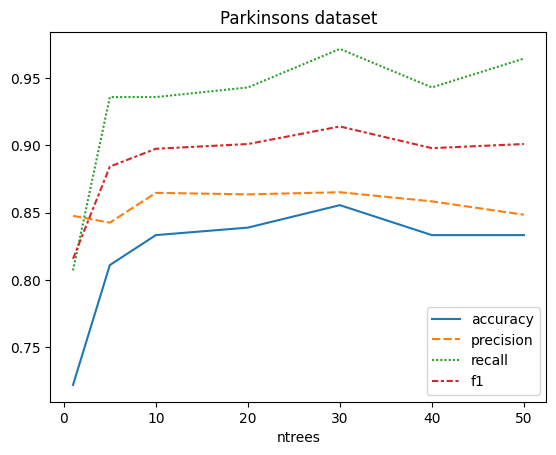

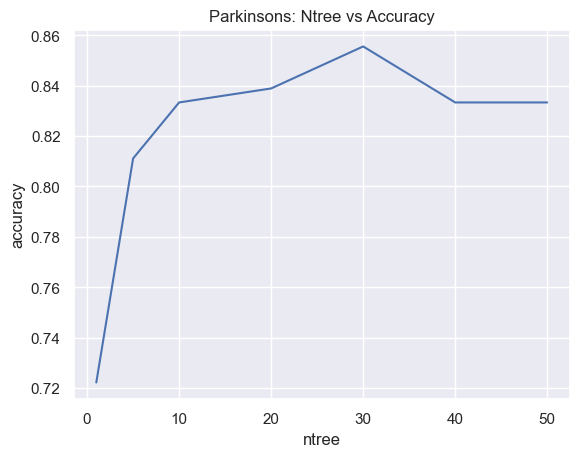

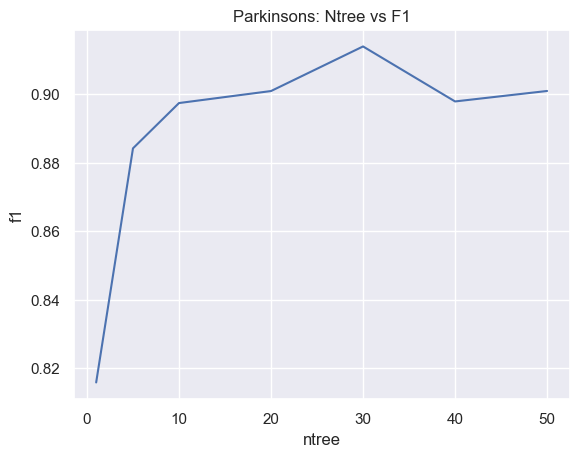

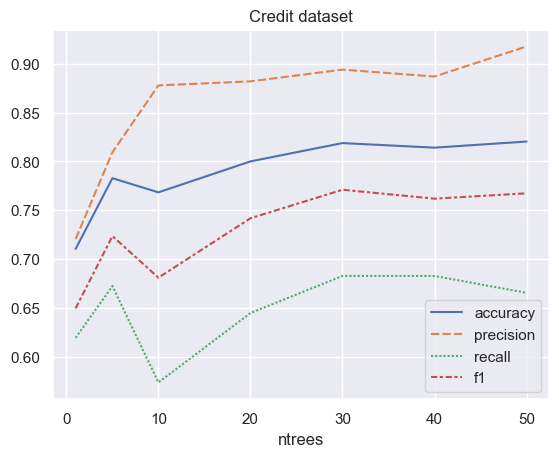

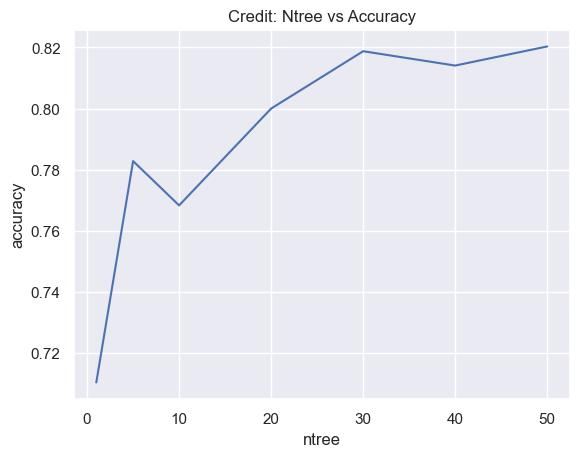

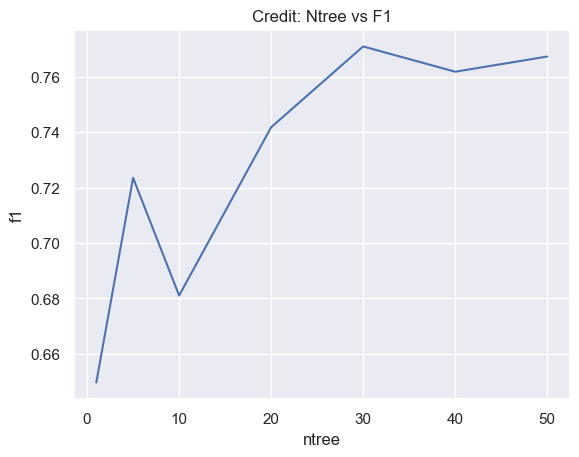

In [28]:
datasets = ["Parkinsons", "Credit"]
for d in datasets:
    plot_metrics(eval(f"{d.lower()}_metrics"), d)

In [10]:
rice_df['label'].value_counts()

label
Osmancik    2180
Cammeo      1630
Name: count, dtype: int64

In [19]:
ntrees = [1, 5, 10, 20, 30, 40, 50]
rice_metrics_classes = evaluate_forest_classes(rice_df, ntrees, 'label', pos_class='Cammeo', neg_class='Osmancik', max_depth=10)

Finished 1 trees
Finished 5 trees
Finished 10 trees
Finished 20 trees
Finished 30 trees
Finished 40 trees
Finished 50 trees


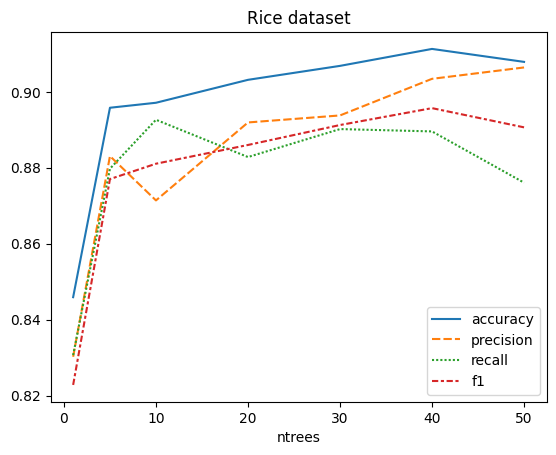

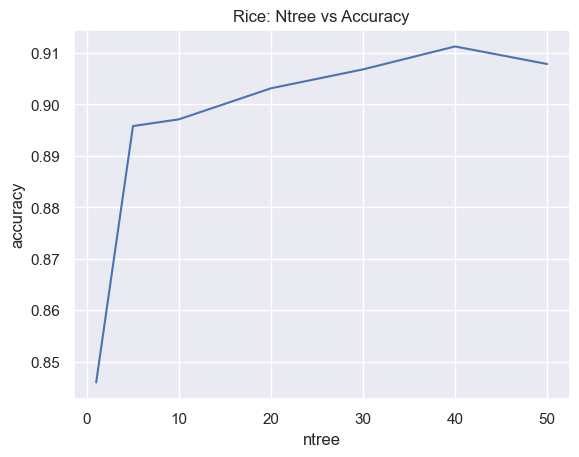

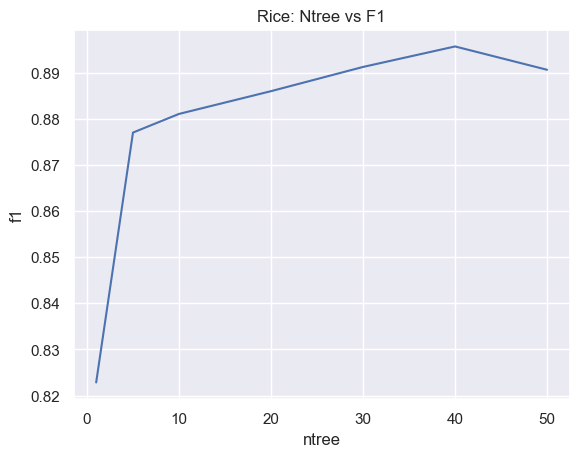

In [21]:
plot_metrics(eval(f"rice_metrics_classes"), "Rice")